# The neutrino slice through the collider detector

Muons decaying in the straight section send neutrinos through the muon-collider
detector itself. This notebook characterises that flux -- how many neutrinos,
where they cross, when they arrive, and how their angle and energy correlate --
using the same MINT simulation as the forward-detector studies, but pointed at
the experiment rather than at a detector kilometres downstream.

The detector geometry is in `muc_detector.py`: a tungsten nozzle shielding the
interaction point, then ECAL, HCAL, the solenoid and the muon spectrometer, all
built from MINT volumes. Optionally the beam-pipe shielding of the straight
section is added, so a neutrino can be traced from its decay point through
everything in its way.


In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import mint
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt

import muc_detector as mud

os.makedirs("plots", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110})

det = mud.muc_detector()
print(f"{len(det.volumes)} volumes, "
      f"half-length {mud.DETECTOR_HALF_LENGTH/100:.1f} m, "
      f"radius {mud.DETECTOR_RADIUS/100:.2f} m")

24 volumes, half-length 5.6 m, radius 6.45 m


## 1. The geometry

A density map through the $(z, r)$ plane. The nozzle is the dominant feature:
it is what shields the detector from the beam, and it is also most of what a
forward neutrino has to cross.

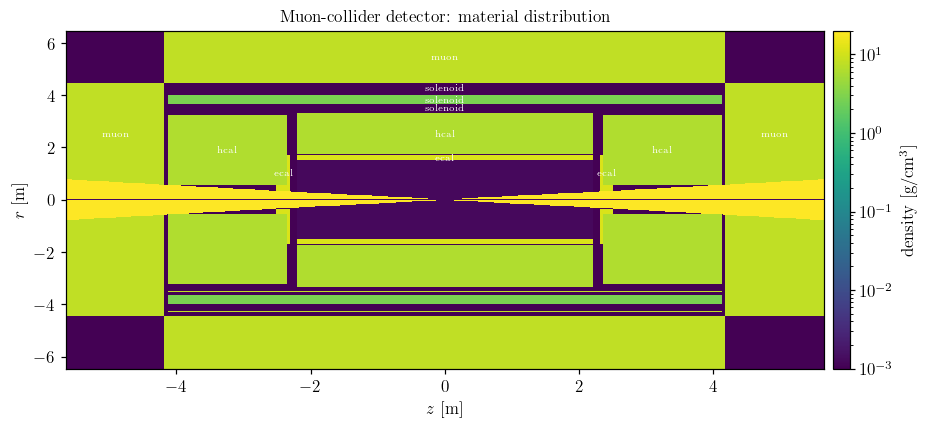

In [2]:
z = np.linspace(-mud.DETECTOR_HALF_LENGTH, mud.DETECTOR_HALF_LENGTH, 900)
r = np.linspace(0, mud.DETECTOR_RADIUS, 420)
rho = mud.density_map(det, z, r)

fig, ax = plt.subplots(figsize=(9, 4.0))
m = ax.pcolormesh(z / 100, r / 100, np.maximum(rho, 1e-4).T,
                  norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis",
                  shading="auto")
ax.pcolormesh(z / 100, -r / 100, np.maximum(rho, 1e-4).T,
              norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis", shading="auto")
cb = fig.colorbar(m, ax=ax, pad=0.01)
cb.set_label(r"density [g/cm$^3$]")

for name, _, r_in, r_out, z0, z1 in mud.REGIONS:
    if name in ("beam_pipe", "tracker_volume"):
        continue
    ax.text(0.5 * (z0 + z1) / 100, 0.5 * (r_in + r_out) / 100,
            name.split("_")[0], fontsize=6, ha="center", va="center",
            color="w")

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$r$ [m]")
ax.set_title("Muon-collider detector: material distribution", fontsize=11)
fig.tight_layout()
fig.savefig("plots/slice_detector_density.pdf", bbox_inches="tight")

## 2. How much material does a neutrino cross?

Column density as a function of the angle the neutrino makes with the beam.
On axis the answer is zero -- the beam pipe is clear all the way through, which
is what makes the slice measurable at all. Just off axis it rises to hundreds of
interaction lengths of tungsten, then falls once the ray clears the nozzle.

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_36524/2203322466.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


on axis:            1.4 g/cm^2
worst case:         2.101e+04 g/cm^2 at 3.90 mrad


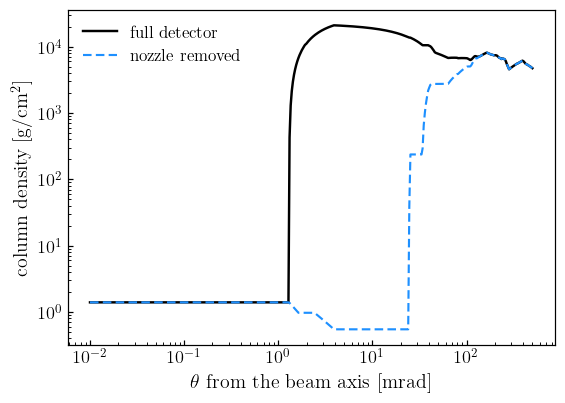

In [3]:
theta = np.geomspace(1e-5, 0.5, 400)
n = theta.size
origin = np.zeros((3, n))
origin[2] = -2 * mud.DETECTOR_HALF_LENGTH
direction = np.zeros((3, n))
direction[0], direction[2] = np.sin(theta), np.cos(theta)

col_full = mud.column_along(det, origin, direction)
col_nonoz = mud.column_along(mud.muc_detector(with_nozzle=False),
                             origin, direction)

fig, ax = pt.std_fig(figsize=(5.6, 4))
ax.plot(theta * 1e3, col_full * const.m_proton_in_g, color="black", lw=1.6,
        label="full detector")
ax.plot(theta * 1e3, col_nonoz * const.m_proton_in_g, color="dodgerblue",
        lw=1.4, ls=(0, (4, 2)), label="nozzle removed")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ from the beam axis [mrad]", fontsize=13)
ax.set_ylabel(r"column density [g/cm$^2$]", fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_column_vs_angle.pdf", bbox_inches="tight")

print(f"on axis:            {col_full[0]*const.m_proton_in_g:.1f} g/cm^2")
i = np.argmax(col_full)
print(f"worst case:         {col_full[i]*const.m_proton_in_g:.3e} g/cm^2 "
      f"at {theta[i]*1e3:.2f} mrad")

## 3. The neutrinos that reach the detector

Simulate the $\mu^+$ beam and keep the decays whose neutrinos cross the
detector envelope. The interaction weight of each is its column density times
the cross section, so the event distribution follows the material, not just the
flux.

In [4]:
N_EVALS = 4e5
ring, sims, ipy = mint.examples.both_beams(n_evals=N_EVALS)
print(f"{ipy:.3e} injections/yr")

def rays(sim):
    (ox, oy, oz), (vx, vy, vz) = dt.sim_rays(sim)
    return np.vstack([ox, oy, oz]), np.vstack([vx, vy, vz])

sim = sims["numubar"]
o, d = rays(sim)
w = sim.weights.flatten() * ipy
E = np.asarray(sim.pnu["E"])

# Decays happen all round the ring; the slice is the flux crossing the
# detector, so weight each ray by the material it actually traverses.
col = mud.column_along(det, o, d)
sig = mint.xsecs.sigma_CC(E, "numubar") + mint.xsecs.sigma_NC_nubar(E)
n_int = w * col * sig

print(f"rays crossing any material: {(col > 0).sum()} of {col.size}")
print(f"nu interactions in the detector: {n_int.sum():.3e} / year")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


5.023e+07 injections/yr


rays crossing any material: 58244 of 374898
nu interactions in the detector: 8.999e+10 / year


## 4. Where the interactions happen

Which subdetector absorbs the slice. The nozzle takes most of it, which is the
point of the nozzle, but the endcaps and the muon spectrometer see a
non-negligible share.

region                    events/yr    share
nozzle_dn_6               1.521e+10   16.9%
nozzle_up_6               1.481e+10   16.5%
nozzle_dn_251             1.280e+10   14.2%
nozzle_dn_418             1.191e+10   13.2%
nozzle_up_251             1.187e+10   13.2%
nozzle_up_418             1.063e+10   11.8%
muon_barrel               3.051e+09    3.4%
nozzle_dn_231             1.568e+09    1.7%
nozzle_up_231             1.487e+09    1.7%
muon_endcap_up            1.343e+09    1.5%
muon_endcap_dn            1.287e+09    1.4%
hcal_barrel               1.028e+09    1.1%
hcal_endcap_up            7.007e+08    0.8%
hcal_endcap_dn            6.860e+08    0.8%
nozzle_dn_413             4.017e+08    0.4%
nozzle_up_413             3.651e+08    0.4%
solenoid_coil             2.522e+08    0.3%
ecal_barrel               2.447e+08    0.3%
solenoid_outer            1.234e+08    0.1%
ecal_endcap_up            7.538e+07    0.1%
ecal_endcap_dn            7.352e+07    0.1%
solenoid_inner            6.490

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_36524/215225576.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


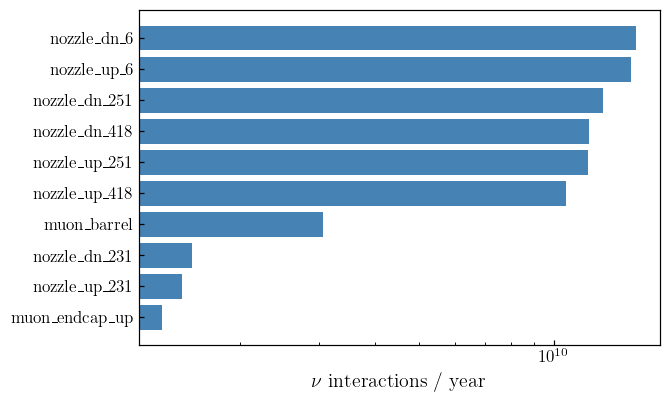

In [5]:
chords = mud.chords_by_region(det, o, d)
rows = []
for name, ch in chords.items():
    vol = next(v for v in det.volumes if v.name == name)
    rows.append((name, (w * ch * vol.material.N * sig).sum()))
rows.sort(key=lambda t: -t[1])
tot = sum(r[1] for r in rows)

print(f"{'region':<22s}{'events/yr':>13s}{'share':>9s}")
for name, v in rows:
    if v > 0:
        print(f"{name:<22s}{v:13.3e}{v/tot:>8.1%}")

names = [r[0] for r in rows if r[1] > 0][:10]
vals = [r[1] for r in rows if r[1] > 0][:10]
fig, ax = pt.std_fig(figsize=(6, 4))
ax.barh(range(len(names)), vals, color="steelblue")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel(r"$\nu$ interactions / year", fontsize=13)
ax.tick_params(which="both", direction="in", labelsize=11)
fig.tight_layout()
fig.savefig("plots/slice_events_by_region.pdf", bbox_inches="tight")

## 5. Radius and angle at the detector

Where the flux crosses the plane of the interaction point, and how radius
correlates with the neutrino's angle to the beam. The correlation is the
signature of the decay kinematics folded with the beam divergence.

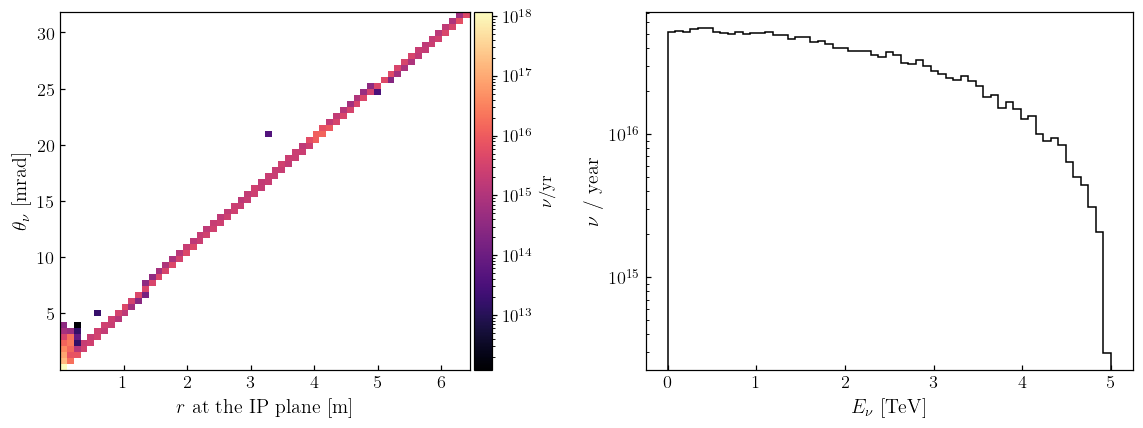

In [6]:
t_ip = -o[2] / d[2]
x_ip, y_ip = o[0] + t_ip * d[0], o[1] + t_ip * d[1]
r_ip = np.hypot(x_ip, y_ip)
theta_nu = np.arctan2(np.hypot(d[0], d[1]), d[2])

keep = (t_ip > 0) & (r_ip < mud.DETECTOR_RADIUS)

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4))
h = axs[0].hist2d(r_ip[keep] / 100, theta_nu[keep] * 1e3, bins=(60, 60),
                  weights=w[keep], norm=LogNorm(), cmap="magma")
fig.colorbar(h[3], ax=axs[0], pad=0.01, label=r"$\nu$/yr")
axs[0].set_xlabel(r"$r$ at the IP plane [m]", fontsize=13)
axs[0].set_ylabel(r"$\theta_\nu$ [mrad]", fontsize=13)

axs[1].hist(E[keep] / 1e3, bins=np.linspace(0, 5, 60), weights=w[keep],
            histtype="step", color="black", lw=1.6)
axs[1].set_xlabel(r"$E_\nu$ [TeV]", fontsize=13)
axs[1].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[1].set_yscale("log")
for a in axs:
    a.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_radius_angle.pdf", bbox_inches="tight")

## 6. Arrival time and pseudorapidity

Neutrinos from around the ring arrive spread in time relative to the bunch
crossing, because their parents decayed at different points. Pseudorapidity is
the natural variable for comparing against collider-detector acceptances.

median |t| = 373.59 ns
median eta = 8.88


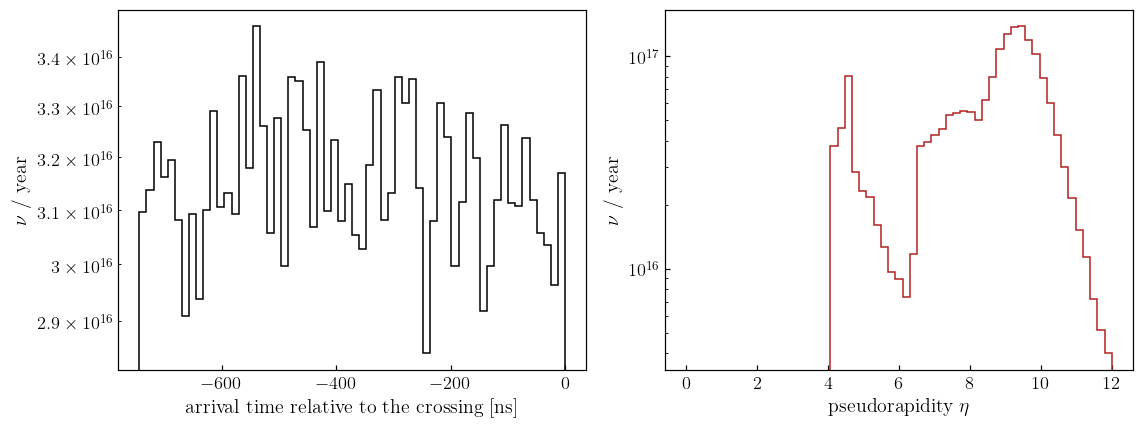

In [7]:
t_ns = np.asarray(sim.mutimes_to_bunchx) * 1e9
eta = -np.log(np.tan(np.clip(theta_nu, 1e-12, np.pi / 2) / 2))

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4))
axs[0].hist(t_ns[keep], bins=60, weights=w[keep], histtype="step",
            color="black", lw=1.6)
axs[0].set_xlabel(r"arrival time relative to the crossing [ns]", fontsize=13)
axs[0].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[0].set_yscale("log")

axs[1].hist(eta[keep], bins=np.linspace(0, 12, 60), weights=w[keep],
            histtype="step", color="firebrick", lw=1.6)
axs[1].set_xlabel(r"pseudorapidity $\eta$", fontsize=13)
axs[1].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[1].set_yscale("log")
for a in axs:
    a.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_time_eta.pdf", bbox_inches="tight")

print(f"median |t| = {np.median(np.abs(t_ns[keep])):.2f} ns")
print(f"median eta = {np.median(eta[keep]):.2f}")

## 7. Adding the beamline shielding

The straight section carries a tungsten liner around the beam pipe. Including
it shows what a neutrino crosses between its decay point and the experiment,
on the same footing as the forward-detector studies.

96 volumes with the shielding included
StraightSectionShield(|z| < 180 m, 36 segments, aperture 2.0-10.3 cm, wall 2.53-4.50 cm W)


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_36524/1736912933.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


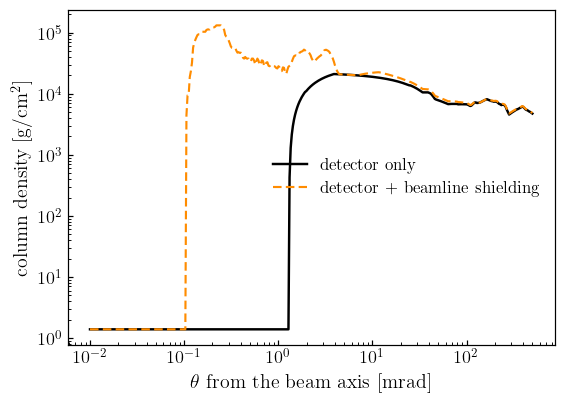

In [8]:
stack, bl = mud.with_beamline(det, lattice=ring)
print(f"{len(stack.volumes)} volumes with the shielding included")
print(bl.shield)

col_shielded = mud.column_along(stack, origin, direction)
fig, ax = pt.std_fig(figsize=(5.6, 4))
ax.plot(theta * 1e3, col_full * const.m_proton_in_g, color="black", lw=1.6,
        label="detector only")
ax.plot(theta * 1e3, col_shielded * const.m_proton_in_g, color="darkorange",
        lw=1.4, ls=(0, (4, 2)), label="detector + beamline shielding")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ from the beam axis [mrad]", fontsize=13)
ax.set_ylabel(r"column density [g/cm$^2$]", fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_column_with_shield.pdf", bbox_inches="tight")

## Notes

- The geometry is a **response model**: where the material is and what it is
  made of. Nothing here parameterises resolution or efficiency, so the event
  counts are interaction rates, not reconstructed yields.
- Regions overlap by construction where a nozzle cone surrounds the beam pipe.
  The nozzle is built as a `HollowCone`, the difference of two MINT volumes, so
  an on-axis neutrino crosses no tungsten -- the check in section 2.
- The tracker is folded into the air volume it occupies rather than modelled
  layer by layer; it contributes negligibly to the column compared with the
  calorimeters and the nozzle.
